In [21]:
import pandas as pd

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier

%matplotlib inline
sns.set_style("whitegrid")

In [23]:
data=pd.read_csv('E:\\vinayak\\RFPForge\\ML-MODEL\\Data\\diabetes.csv')

In [24]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [25]:
print("\nStatistical Summary")
display(data.describe())


Statistical Summary


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [26]:
# X = data[:,0:8]
# y = data[:,-1] # Assuming the last column is the target variable
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.3, random_state=42
# )

In [27]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# =========================
# 1. Load Dataset
# =========================
data = pd.read_csv("E:\\vinayak\\RFPForge\\ML-MODEL\\Data\\diabetes.csv")

# =========================
# 2. Preprocessing
# =========================
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
data[cols_with_zero] = data[cols_with_zero].replace(0, np.nan)
data.fillna(data.median(), inplace=True)

X = data.drop("Outcome", axis=1)
y = data["Outcome"]

# =========================
# 3. Train-Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# 4. Models Setup (Pipeline)
# =========================
models = {
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000))
    ]),
    
    "Random Forest": Pipeline([
        ('model', RandomForestClassifier(n_estimators=200, random_state=42))
    ]),
    
    "XGBoost": Pipeline([
        ('model', XGBClassifier(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric='logloss',
            random_state=42
        ))
    ]),
    
    "SVM": Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(probability=True))
    ]),
    
    "KNN": Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=5))
    ])
}

# =========================
# 5. Train & Evaluate
# =========================
results = []

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

# =========================
# 6. Convert to DataFrame
# =========================
results_df = pd.DataFrame(results)

# Sort by best model
results_df = results_df.sort_values(by="F1 Score", ascending=False)

print("\nModel Comparison Table:\n")
print(results_df)


Model Comparison Table:

                 Model  Accuracy  Precision    Recall  F1 Score
4                  KNN  0.753247   0.660000  0.611111  0.634615
2              XGBoost  0.746753   0.647059  0.611111  0.628571
1        Random Forest  0.740260   0.652174  0.555556  0.600000
3                  SVM  0.740260   0.652174  0.555556  0.600000
0  Logistic Regression  0.707792   0.600000  0.500000  0.545455


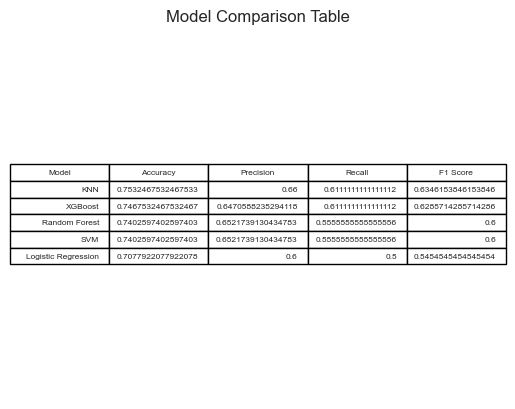

In [28]:
import matplotlib.pyplot as plt

plt.figure()
plt.table(
    cellText=results_df.values,
    colLabels=results_df.columns,
    loc='center'
)

plt.axis('off')
plt.title("Model Comparison Table")
plt.show()

In [39]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    recall_score,
    precision_score,
    f1_score,
    precision_recall_curve
)
from sklearn.preprocessing import StandardScaler

from xgboost import XGBClassifier
import joblib
from sklearn.metrics import f1_score

# =========================
# 1. Load Dataset
# =========================
data = pd.read_csv(r"E:\vinayak\RFPForge\ML-MODEL\Data\diabetes.csv")

# =========================
# 2. Preprocessing
# =========================
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
data[cols_with_zero] = data[cols_with_zero].replace(0, np.nan)

# Fill missing values
data.fillna(data.median(), inplace=True)

# =========================
# 3. Features & Target
# =========================
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

# =========================
# 4. Train-Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# 5. Scaling
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================
# 6. Handle Class Imbalance
# =========================
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# =========================
# 7. Train XGBoost Model
# =========================
model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

# =========================
# 8. Predictions (PROBABILITY BASED)
# =========================
y_prob = model.predict_proba(X_test)[:, 1]

# =========================
# 9. Find Best Threshold (for high recall)
# =========================


best_threshold = 0.35 -0.40
best_f1 = 0

for t in thresholds:
    y_pred_temp = (y_prob > t).astype(int)
    f1 = f1_score(y_test, y_pred_temp)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(f"Best Threshold (F1 optimized): {best_threshold:.3f}")

# Apply threshold
y_pred = (y_prob > best_threshold).astype(int)

# =========================
# 10. Evaluation
# =========================
print("\n===== MODEL PERFORMANCE =====")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Recall:", recall_score(y_test, y_pred))   # 🔥 MOST IMPORTANT
print("Precision:", precision_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

# =========================
# 11. Save Model + Scaler + Threshold
# =========================
joblib.dump(model, "xgboost_diabetes_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(best_threshold, "threshold.pkl")

print("\n✅ Model, scaler, and threshold saved successfully!")

Best Threshold (F1 optimized): 0.324

===== MODEL PERFORMANCE =====
Accuracy: 0.7597402597402597
ROC-AUC: 0.8287037037037037
Recall: 0.8703703703703703
Precision: 0.6103896103896104
F1 Score: 0.7175572519083969

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.70      0.79       100
           1       0.61      0.87      0.72        54

    accuracy                           0.76       154
   macro avg       0.76      0.79      0.75       154
weighted avg       0.80      0.76      0.77       154


✅ Model, scaler, and threshold saved successfully!


In [30]:
model = joblib.load("xgboost_diabetes_model.pkl")
scaler = joblib.load("scaler.pkl")

def predict(input_data):
    input_scaled = scaler.transform([input_data])
    pred = model.predict(input_scaled)
    prob = model.predict_proba(input_scaled)

    return pred, prob

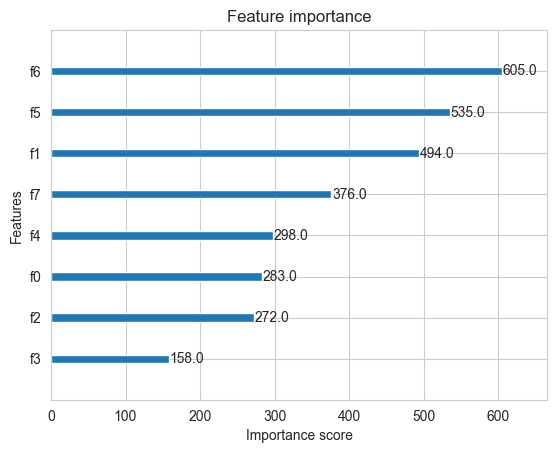

In [31]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(model)
plt.show()

In [32]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier
import numpy as np

# Define model
model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

# Stratified K-Fold
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validation scores
cv_accuracy = cross_val_score(model, X, y, cv=kfold, scoring='accuracy')
cv_auc = cross_val_score(model, X, y, cv=kfold, scoring='roc_auc')

print("Cross-Validation Accuracy:", cv_accuracy)
print("Mean Accuracy:", np.mean(cv_accuracy))

print("\nCross-Validation ROC-AUC:", cv_auc)
print("Mean ROC-AUC:", np.mean(cv_auc))

Cross-Validation Accuracy: [0.78571429 0.77922078 0.77272727 0.75163399 0.7124183 ]
Mean Accuracy: 0.7603429250488075

Cross-Validation ROC-AUC: [0.84907407 0.84759259 0.82111111 0.81037736 0.77641509]
Mean ROC-AUC: 0.8209140461215932


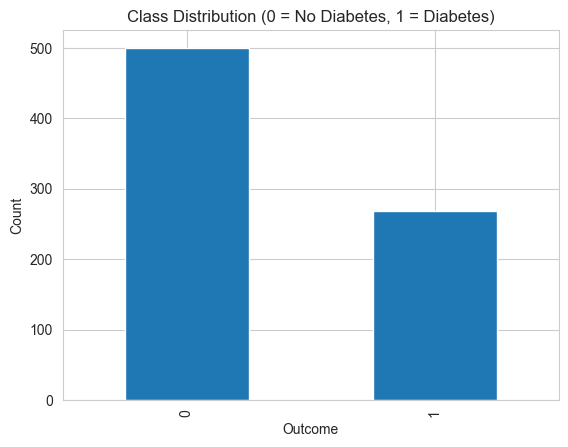

In [33]:
import matplotlib.pyplot as plt

data['Outcome'].value_counts().plot(kind='bar')
plt.title("Class Distribution (0 = No Diabetes, 1 = Diabetes)")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.show()

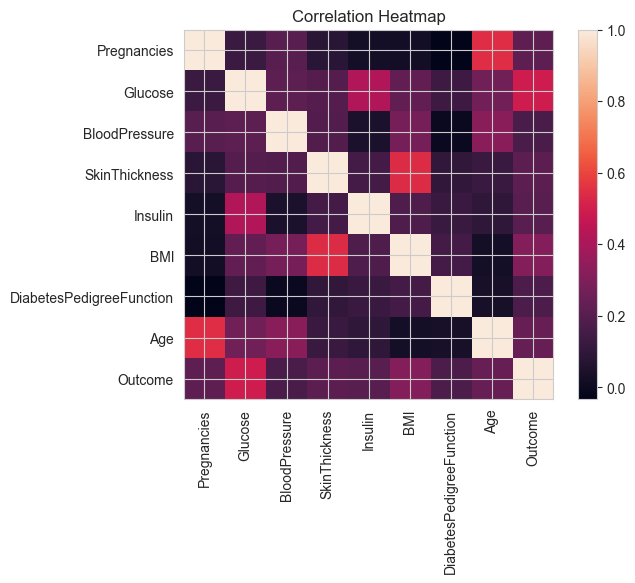

In [34]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(data.corr(), interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(data.columns)), data.columns, rotation=90)
plt.yticks(range(len(data.columns)), data.columns)
plt.title("Correlation Heatmap")
plt.show()

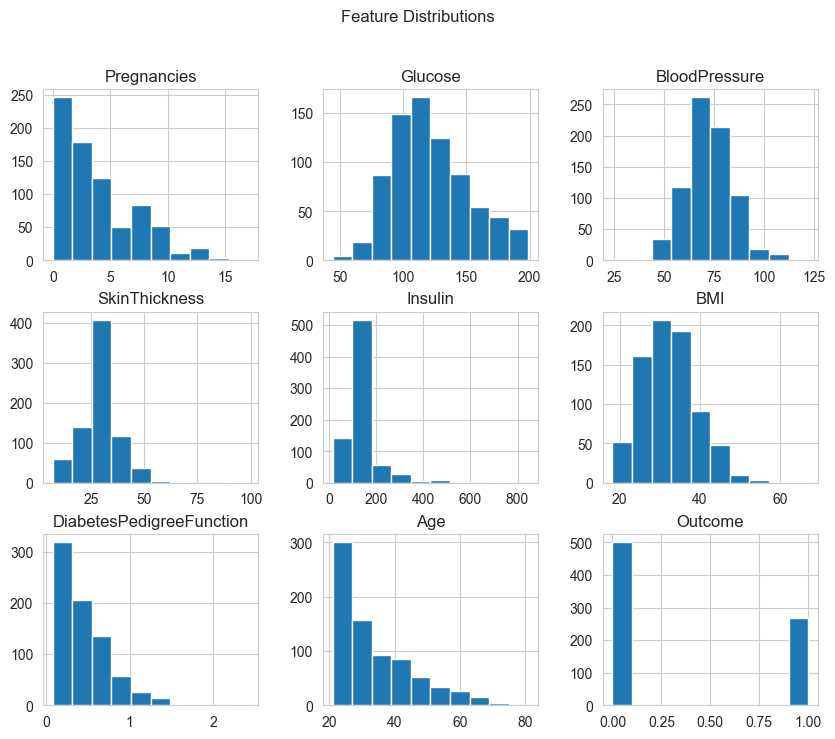

In [35]:
data.hist(figsize=(10,8))
plt.suptitle("Feature Distributions")
plt.show()

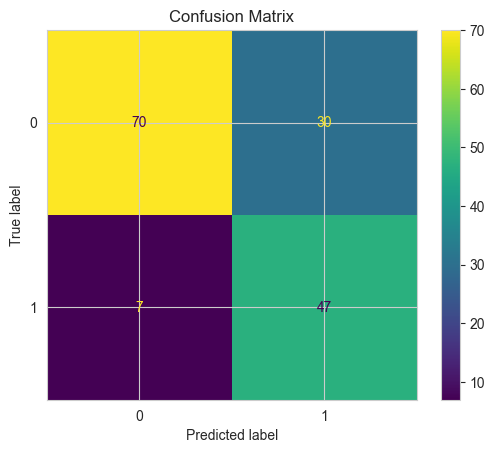

In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

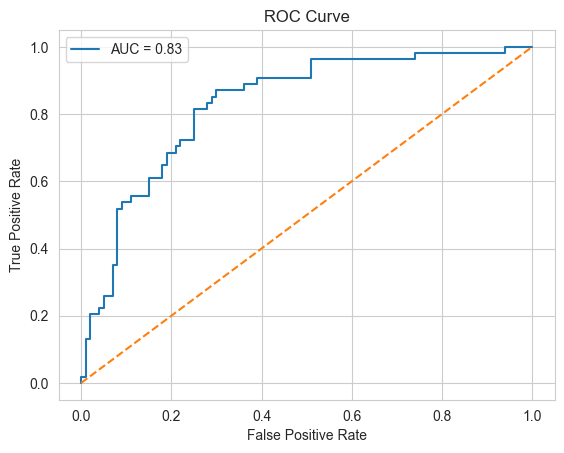

In [37]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [38]:
from xgboost import plot_importance

plot_importance(model)
plt.title("Feature Importance (XGBoost)")
plt.show()

NotFittedError: need to call fit or load_model beforehand

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [ ]:
import shap

explainer = shap.Explainer(model)
shap_values = explainer(X)

shap.plots.bar(shap_values)

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# =========================
# 1. Load Dataset
# =========================
data = pd.read_csv(r"E:\vinayak\RFPForge\ML-MODEL\Data\diabetes.csv")

# =========================
# 2. Preprocessing
# =========================
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
data[cols_with_zero] = data[cols_with_zero].replace(0, np.nan)
data.fillna(data.median(), inplace=True)

X = data.drop("Outcome", axis=1)
y = data["Outcome"]

# =========================
# 3. Train-Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# 4. Models Setup (Pipeline)
# =========================
models = {
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000))
    ]),
    
    "Random Forest": Pipeline([
        ('model', RandomForestClassifier(n_estimators=200, random_state=42))
    ]),
    
    "XGBoost": Pipeline([
        ('model', XGBClassifier(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric='logloss',
            random_state=42
        ))
    ]),
    
    "SVM": Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(probability=True))
    ]),
    
    "KNN": Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=5))
    ])
}

# =========================
# 5. Train & Evaluate
# =========================
results = []

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

# =========================
# 6. Convert to DataFrame
# =========================
results_df = pd.DataFrame(results)

# Sort by best model
results_df = results_df.sort_values(by="F1 Score", ascending=False)

print("\nModel Comparison Table:\n")
print(results_df)

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.table(
    cellText=results_df.values,
    colLabels=results_df.columns,
    loc='center'
)

plt.axis('off')
plt.title("Model Comparison Table")
plt.show()

In [ ]:
from fastapi import FastAPI
from pydantic import BaseModel
import joblib
import numpy as np

# =========================
# 1. Load Model & Scaler
# =========================
model = joblib.load("xgboost_diabetes_model.pkl")
scaler = joblib.load("scaler.pkl")

# =========================
# 2. FastAPI App
# =========================
app = FastAPI(title="Diabetes Prediction API")

# =========================
# 3. Input Schema
# =========================
class PatientData(BaseModel):
    Pregnancies: int
    Glucose: float
    BloodPressure: float
    SkinThickness: float
    Insulin: float
    BMI: float
    DiabetesPedigreeFunction: float
    Age: int

# =========================
# 4. Prediction Function
# =========================
def predict(input_data):
    input_scaled = scaler.transform([input_data])
    pred = model.predict(input_scaled)[0]
    prob = model.predict_proba(input_scaled)[0][1]
    return pred, prob

# =========================
# 5. Root Endpoint
# =========================
@app.get("/")
def home():
    return {"message": "Diabetes Prediction API is running"}

# =========================
# 6. Prediction Endpoint
# =========================
@app.post("/predict")
def predict_disease(data: PatientData):
    
    input_data = [
        data.Pregnancies,
        data.Glucose,
        data.BloodPressure,
        data.SkinThickness,
        data.Insulin,
        data.BMI,
        data.DiabetesPedigreeFunction,
        data.Age
    ]

    pred, prob = predict(input_data)

    return {
        "prediction": int(pred),
        "risk_probability": float(prob),
        "interpretation": "High Risk" if pred == 1 else "Low Risk"
    }